In [1]:
import sys, os
sys.path.insert(0, '..')

import numpy  as np
import tensorflow as tf
import math
import pandas as pd

from model.data import getDataETTh1,Normalize
from model.model import myInformer
from model.exp import Exp

import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

from tqdm import tqdm

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [3]:
# EXP
d_model = 512
HEADS = 8
RATE = 0.05
SEQ_LEN = 96
FACTOR = 5
BATCH_SIZE = 32
GLOBAL_SIZE = 0
d_ff= 2048
E_LAYERS = 2
D_LAYERS = 1
PRED_LEN =24
FEATURES= 4
TIME_FEATURES = 3
EPOCHS = 5
EMBED_FREQ = 'r'
DATA_SOURCE = 'GAS'
settings = {'batch_size':BATCH_SIZE, 'seq_len':SEQ_LEN, 'global_size':GLOBAL_SIZE, 'd_model':d_model, 'd_ff':d_ff, 'e_layer': E_LAYERS,
            'd_layer':D_LAYERS, 'rate':RATE, 'factor':FACTOR, 'heads':HEADS, 'pred_len':PRED_LEN, 'features':FEATURES, 'timeFeatures':TIME_FEATURES, 'freq':EMBED_FREQ,
            'data_source':DATA_SOURCE}
# print(settings)
# Creation du model Exp
myExpFct = Exp(settings)
myExpFct.build(split=0.2)
myExpFct._buildModel(0.000_15)
# model = myExpFct.train(EPOCHS)

count    3226.000000
mean        2.015809
std         1.403229
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         4.000000
Name: sJour, dtype: float64


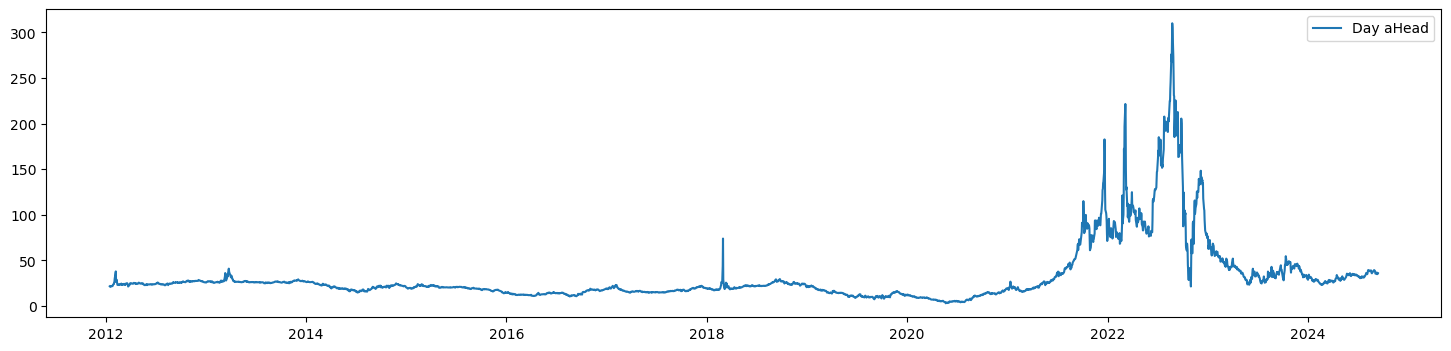

In [4]:
myExpFct.dataFct.display()
print(myExpFct.dataFct.df_Data['sJour'].describe())

In [ ]:
# SAVE MODEL
# from tensorflow import train
# # Create a checkpoint object and manager to manage multiple checkpoints
# ckpt = train.Checkpoint(model=myExpFct.modelFct, optimizer=myExpFct.optimizer)
# ckpt_manager = train.CheckpointManager(ckpt, "./checkpoints", max_to_keep=3)
# # Save a checkpoint after every five epochs
# save_path = ckpt_manager.save()
# print("Saved checkpoint")
# # Save the trained model weights
# myExpFct.modelFct.save_weights("weights/wghts" + str(EPOCHS) + ".ckpt")
myExpFct.save_model()


In [4]:
def getData(data,init,seq_len=96,pred_len=24):
    dec_len = seq_len//2
    dec_all = dec_len + pred_len
    Xe = data[init:init+seq_len,0:7]
    Xed = data[init:init+seq_len,7:]
    padd = tf.zeros((pred_len,11))
    Xd = tf.concat([data[init:init+dec_len,:7],padd[:,:7]],axis=0)
    Xdd = tf.concat([data[init:init+dec_len,7:],padd[:,7:]],axis=0)
    Xe = tf.reshape(Xe, shape=(1,seq_len,7))
    Xed = tf.reshape(Xed, shape=(1,96,4))
    Xd = tf.reshape(Xd, shape=(1,dec_all,7))
    Xdd = tf.reshape(Xdd, shape=(1,dec_all,4))
    Xr = data[init:init+dec_all,:7]
    Xr = tf.reshape(Xr, shape=(dec_all,7))
    return Xe,Xed,Xd,Xdd,Xr


In [ ]:
# # Creation du model Exp
# myExpFct = Exp(settings)
# myExpFct.build()
# # Chargement du model
# new_modelExp = Exp(settings=settings)
# new_model = new_modelExp.modelFct
# new_model.load_weights('weights/wghts20.ckpt')

new_model = myExpFct.modelFct

# Prédictions ...
init = 300
feat=6
forecast = 100

data = myExpFct.dataFct.data
_,_,_,_,Xi = getData(data,init,96,24)
Xi = Xi[:,:]
print(Xi.shape)
Pi = tf.cast(Xi,tf.float32)
Pimin = Pi
Pimax = Pi
Pia = Pi
Pall = Pi
Mall = Pi[None,-24:,:]
infM = tf.ones(shape=(1,1,7),dtype=tf.float32) * -1.e10
infm = tf.ones(shape=(1,1,7),dtype=tf.float32) * 1.e10
# for i in (range (forecast)):
for i in tqdm(range (init, init+forecast)):
    Xe,Xed,Xd,Xdd,Xr = getData(data,i+1,96,24)
    pred = new_model(Xe,Xed,Xd, Xdd, training=False)[0]
    # predOne = tf.cast(tf.reshape(pred,shape=(PRED_LEN,7)),tf.float32)[None,0,:]
    # predOne = tf.reduce_mean(pred,axis=1)
    predAll = tf.cast(tf.reshape(pred,shape=(PRED_LEN,7)),tf.float32)
    Mall = tf.concat([Mall,pred],axis=0)
    # L,F = Pi.shape
    Li,F = Pia.shape
    # compute min/max
    cM=tf.concat([Pimax[None,-23:,:],infM],axis=1)
    cm=tf.concat([Pimin[None,-23:,:],infm],axis=1)
    bM = tf.concat([pred,cM],axis=0)
    bm = tf.concat([pred,cm],axis=0)
    bmax= tf.reduce_max(bM,axis=0)
    bmin= tf.reduce_min(bm,axis=0)
    Pimax = tf.concat([Pimax[:Li-23,:],bmax],axis=0)
    Pimin = tf.concat([Pimin[:Li-23,:],bmin],axis=0)
    Xi = tf.concat([Xi,Xr[None,-1,:]],axis=0)
    # Pi = tf.concat([Pi,predOne],axis=0)
    Pia = tf.concat([Pia[:Li-23,:],predAll],axis=0)

# L,F = Pi.shape
Li,F = Pia.shape
# Pi = myExpFct.scaler.inverse_transform(tf.reshape(Pi,shape=(L,F)))
PCia = myExpFct.scaler.inverse_transform(tf.reshape(Pia,shape=(Li,F)))
PCimax = myExpFct.scaler.inverse_transform(tf.reshape(Pimax,shape=(Li,F)))
PCimin = myExpFct.scaler.inverse_transform(tf.reshape(Pimin,shape=(Li,F)))
# x_padd = tf.zeros(shape=(48,7))
# pred = tf.concat([x_padd,pred],axis=0)
# print(pred.shape)

x_ = myExpFct.scaler.inverse_transform(Xi)
df_raw = myExpFct.dataFct.df_Data

v_min = math.ceil( tf.reduce_min(x_[:,feat]) / 10.) * 10. - 10.
v_max = math.floor( (math.ceil( tf.reduce_max(x_[:,feat])/10.) * 10) )

deb = 48 +1 + forecast
fin = 72 + forecast


In [ ]:

fig = plt.figure(figsize=(18,10))
plt.ylim(v_min, v_max )
# plt.plot(range(48, fin),Pi[48:fin,feat], 'r--', label="Predicted");
plt.plot(range(48, fin),PCia[48:fin,feat], 'r--', label="Predicted");
# sns.lineplot(x=range(0,fin),y="Pred", data=df, hue=dfGrp); #,hue=PCimax[:,6]);
plt.plot(range(0, fin),PCimax[0:fin,feat], 'r:');
plt.plot(range(0, fin),PCimin[0:fin,feat], 'b:');
plt.fill_between(x=range(0,fin), y1=PCimax[:,6], y2=PCimin[:,6], alpha=0.10, color='tab:orange')
plt.plot(range(0,49),x_[0:49,feat], label="Training");
plt.plot(range(48,fin-24),x_[48:fin-24,feat], 'g', label="Réel Passé");
plt.plot(range(0,fin),df_raw['OT'][init:fin+init], 'g:', label="Futur Réel ?");
# plt.plot(range(fin-24,fin),df_raw['OT'][fin+init-24:fin+init], 'g:', label="Futur Réel ?");
plt.legend();

In [ ]:

print(Mall.shape)

fig = plt.figure(figsize=(18,10))
plt.plot(range(47,48+forecast), Xi[47:48+forecast,6], 'g', label='true')
for i in range(1,forecast+1):
    plt.plot(range(48+i,72+i),Mall[i,:,6], 'b:')
    # plt.plot(range(1,25),Mall[2,:,6], 'y:', label='true')
    # plt.plot(range(2,26),Mall[3,:,6], 'g:', label='true')
    # plt.plot(range(3,27),Mall[4,:,6], 'r:', label='true')
    # plt.plot(range(4,28),Mall[5,:,6], 'v:', label='true')
    # plt.plot(range(0,28),Pia[48:48+29,6], 'r--', label='true')
plt.plot(range(0,48),Xi[:48,6], 'b', label='true')
plt.plot(range(47+forecast,Xi.shape[0]), Xi[47+forecast:,6], 'b')
# plt.plot(range(0,Xi.shape[0]),Xi[:,6], 'b', label='true')
plt.plot(range(48,Pimax.shape[0]),Pimax[48:,6], 'g--', label='Max')
plt.plot(range(48,Pimin.shape[0]),Pimin[48:,6], 'y--', label='Max')
# plt.plot(range(0,24+forecast-1),Pimin[48:48+24+forecast,6], 'b--', label='true')
plt.plot(range(48,Pia.shape[0]),Pia[48:,6], 'r--', label='true')

# plt.plot(range(48, fin),Pia[48:fin,feat], 'r--', label="Predicted");
# plt.plot(range(48, fin),Pimax[48:fin,feat], 'r:', label="P max");
# plt.plot(range(48, fin),Pimin[48:fin,feat], 'b:', label="P min");
# plt.plot(range(0,49),x_[0:49,feat], label="Training");
# plt.plot(range(48,fin-23),x_[48:fin-23,feat], 'g', label="Réel Passé");
# plt.plot(range(fin-24,fin),df_raw['OT'][fin+init-24:fin+init], 'g:', label="Futur Réel ?");
plt.legend();

In [ ]:
import pandas as pd
print(PCia[:,6].shape, fin)
l = tf.concat([PCimax[None,:,6],PCimin[None,:,6]],axis=0)
print(l.shape)
# df = pd.DataFrame(data=[np.transpose(x_[:,6]),np.transpose(PCia[:,6]),np.transpose(PCimax[:,6]),np.transpose(PCimin[:,6])]) #, columns=['X','Y','Max','Min'])
# df = pd.DataFrame({'Y':(x_[:,6]), 'Pred':PCia[:,6],'Max':PCimax[:,6], 'Min':PCimin[:,6], 'Grp':l[0,:]})
# dfGrp=df.groupby(['Max','Min']).agg({'val','sum'})
# print(df.info())
# print(dfGrp)
fig = plt.figure(figsize=(18,10))
plt.ylim(v_min, v_max )
# plt.plot(range(48, fin),Pi[48:fin,feat], 'r--', label="Predicted");
# plt.plot(range(48, fin),PCia[48:fin,feat], 'r--', label="Predicted");
# sns.lineplot(x=range(0,fin),y="Pred", data=df, hue=dfGrp); #,hue=PCimax[:,6]);
plt.plot(range(0, fin),PCimax[0:fin,feat], 'r:', label="P max");
plt.plot(range(0, fin),PCimin[0:fin,feat], 'b:', label="P min");
plt.fill_between(x=range(0,fin), y1=PCimax[:,6], y2=PCimin[:,6], alpha=0.10, color='tab:orange')
plt.plot(range(0,49),x_[0:49,feat], label="Training");
plt.plot(range(48,fin-23),x_[48:fin-23,feat], 'g', label="Réel Passé");
# plt.plot(range(fin-24,fin),df_raw['OT'][fin+init-24:fin+init], 'g:', label="Futur Réel ?");
plt.legend();

In [ ]:
settings

In [379]:
from pickle import dump
with open('./scaler/scaler.sav', 'wb') as file:
    dump(myExpFct.dataFct.scalerData, file)

with open('./settings/settings.sav', 'wb') as file:
    dump(settings, file)

